# Step 4 — Inferencia CNN (RNC) sobre Eventos Sismicos de MG

**Objetivo:** Classificar eventos sismicos do catalogo MG (M1.2) como Natural ou Antropogenico
usando a rede neural convolucional RNC treinada sobre espectrogramas 3C.

**Entrada:** `data/events_m12_merge_v2/` (189 eventos materializados)

**Modelo:** `models/rnc/model_2021354T1554.h5`

**Metodo:** Para cada estacao-pick (triplet 3C: HHZ, HHN, HHE):
1. Ler waveform merged (.mseed)
2. Decimar para 100 Hz, aplicar detrend/taper/highpass
3. Calcular STA/LTA para filtro de qualidade (CFT >= 1.5)
4. Gerar espectrograma normalizado por canal
5. Empilhar 3 canais e submeter a CNN

Este notebook demonstra o processo completo em 3 eventos exemplo.

## Imports

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import obspy
import tensorflow as tf
from obspy.signal.invsim import cosine_taper
from obspy.signal.trigger import classic_sta_lta

print(f"ObsPy {obspy.__version__}")
print(f"TensorFlow {tf.__version__}")
print(f"NumPy {np.__version__}")

I0000 00:00:1773808085.176738   75034 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773808085.177320   75034 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773808085.224211   75034 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773808086.581521   75034 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

ObsPy 1.5.0
TensorFlow 2.21.0
NumPy 2.4.3


## Configuracao

In [2]:
EVENTS_ROOT = Path("../data/events_m12_merge_v2")
MODEL_PATH = Path("../models/rnc/model_2021354T1554.h5")
WAVEFORM_SUBDIR = "waveform"

# Parametros de preprocessamento (identicos ao pipeline oficial)
TARGET_HZ = 100.0
CFT_MIN = 1.5
REQUIRED_CHANNELS = ["HHZ", "HHN", "HHE"]

# Parametros de espectrograma
WINDOW_LENGTH_S = 1.0
STEP_LENGTH_S = 0.25  # 75% overlap
EXPECTED_SHAPE = (237, 50)  # shape esperado por canal

# Eventos exemplo para demonstracao
EXAMPLE_EVENT_IDS = ["2020020T210424", "2020030T152418", "2020022T221808"]

print(f"events_root={EVENTS_ROOT}")
print(f"model_path={MODEL_PATH}")
print(f"model_exists={MODEL_PATH.exists()}")
print(f"events_count={len(list(EVENTS_ROOT.iterdir()))}")

events_root=../data/events_m12_merge_v2
model_path=../models/rnc/model_2021354T1554.h5
model_exists=True
events_count=189


## Justificativa para funcoes auxiliares

O preprocessamento de espectrogramas envolve operacoes repetidas por canal e por triplet:
decimacao, FFT janelada, taper, normalizacao. Duplicar esse codigo inline para cada
evento tornaria o notebook ilegivel. As funcoes abaixo replicam **exatamente** a logica
de `src/seismic_event_discriminator/rnc_infer.py` sem importar nenhum modulo do projeto.

Conforme `docs/tlc_diretrizes_jupyter_notebooks.md`, secao "Quando abstrair (excecao)":
> Somente introduzir funcao quando houver repeticao clara que dificulta leitura
> por excesso de codigo duplicado.

## Funcoes auxiliares de preprocessamento

Cada funcao replica exatamente o codigo de `rnc_infer.py` (linhas 28-229).

In [3]:
import matplotlib.mlab as mlab


def stride_windows(x, n, noverlap=None, axis=0):
    """Cria janelas FFT com stride (replica rnc_infer.py L28-55)."""
    if noverlap is None:
        noverlap = 0
    if noverlap >= n:
        raise ValueError("noverlap must be less than n")
    x = np.asarray(x)
    if x.ndim != 1:
        raise ValueError("only 1-dimensional arrays can be used")
    if n == 1 and noverlap == 0:
        if axis == 0:
            return x[np.newaxis]
        return x[np.newaxis].transpose()
    if n > x.size:
        raise ValueError("n cannot be greater than the length of x")
    noverlap = int(noverlap)
    n = int(n)
    step = n - noverlap
    if axis == 0:
        shape = (n, (x.shape[-1] - noverlap) // step)
        strides = (x.strides[0], step * x.strides[0])
    else:
        shape = ((x.shape[-1] - noverlap) // step, n)
        strides = (step * x.strides[0], x.strides[0])
    return np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)


def fft_taper(data):
    """Aplica cosine taper (replica rnc_infer.py L58-61)."""
    return data * cosine_taper(npts=data.size, p=0.2)


def get_fft(trace, window_length_s, step_length_s):
    """Calcula features FFT para um segmento de 1s (replica rnc_infer.py L64-83)."""
    s_rate = float(trace.stats.sampling_rate)
    nb_pts = int(window_length_s * s_rate)
    nb_overlap = int((1.0 - step_length_s) * nb_pts)
    window = fft_taper(np.ones(nb_pts, trace.data.dtype))
    result = stride_windows(trace.data, nb_pts, nb_overlap, axis=0)
    result = mlab.detrend(result, mlab.detrend_linear, axis=0)
    result = result * window.reshape((-1, 1))
    num_freqs = nb_pts // 2 + 1
    result = np.fft.fft(result, n=nb_pts, axis=0)[:num_freqs, :]
    freqs = np.fft.fftfreq(nb_pts, 1 / s_rate)[:num_freqs]
    freqs[-1] *= -1
    result = result[1:]
    freqs = freqs[1:]
    result = np.abs(result) / trace.data.size
    result = result.ravel()
    return result, freqs


def decimate_to_target_hz(trace, target_hz):
    """Decima trace para taxa alvo (replica rnc_infer.py L98-109)."""
    sr = float(trace.stats.sampling_rate)
    if abs(sr - target_hz) < 1e-6:
        return trace
    if sr < target_hz:
        raise ValueError(f"sampling rate abaixo do alvo ({sr} Hz < {target_hz} Hz)")
    factor = sr / target_hz
    rounded = int(round(factor))
    if abs(factor - rounded) > 1e-6 or rounded <= 1:
        raise ValueError(f"taxa nao decimavel por fator inteiro para {target_hz} Hz: {sr} Hz")
    trace.decimate(rounded)
    return trace


def spectrogram_for_trace(trace):
    """Gera espectrograma normalizado para um canal (replica rnc_infer.py L112-128)."""
    fft_list = []
    start = trace.stats.starttime
    end = trace.stats.endtime
    while start + WINDOW_LENGTH_S <= end:
        tr = trace.slice(starttime=start, endtime=start + WINDOW_LENGTH_S)
        start += STEP_LENGTH_S
        fft_vals, _ = get_fft(tr, window_length_s=WINDOW_LENGTH_S, step_length_s=STEP_LENGTH_S)
        fft_list.append(np.array(fft_vals))
    out = np.array(fft_list)
    if tuple(out.shape) != EXPECTED_SHAPE:
        raise ValueError(f"shape invalido {tuple(out.shape)} esperado {EXPECTED_SHAPE}")
    vmax = float(out.max()) if out.size else 0.0
    if vmax <= 0.0:
        raise ValueError("espectrograma max e zero")
    out /= vmax
    return out


print("Funcoes auxiliares definidas.")

Funcoes auxiliares definidas.


## Carregar modelo CNN

In [4]:
model = tf.keras.models.load_model(str(MODEL_PATH), compile=False)
model.summary()

/home/gabrielgoes/.pyenv/versions/geo-seis-rnc/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773808087.593591   75034 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 233, 46, 18)    │         1,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 116, 23, 18)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 114, 21, 36)    │         5,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 57, 10, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 55, 8, 68)      │        22,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 27, 4, 68)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 26, 3, 68)      │        18,564 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 1, 68)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 884)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 80)             │        70,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 80)             │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           162 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,342 (489.62 KB)

 Trainable params: 125,342 (489.62 KB)

 Non-trainable params: 0 (0.00 B)

## Listar eventos exemplo e seus waveforms

In [5]:
for event_id in EXAMPLE_EVENT_IDS:
    event_dir = EVENTS_ROOT / event_id
    waveform_dir = event_dir / WAVEFORM_SUBDIR
    mseed_files = sorted(waveform_dir.glob("*.mseed"))
    print(f"\n{event_id}: {len(mseed_files)} waveforms")
    for f in mseed_files:
        print(f"  {f.name}")


2020020T210424: 7 waveforms
  BL_BB19B_2020020T210424.mseed
  BL_BSCB_2020020T210424.mseed
  BL_CANS_2020020T210424.mseed
  BL_ITRB_2020020T210424.mseed
  BL_PMNB_2020020T210424.mseed
  BL_RCLB_2020020T210424.mseed
  BR_IPMB_2020020T210424.mseed

2020030T152418: 7 waveforms
  BL_BSCB_2020030T152418.mseed
  BL_CANS_2020030T152418.mseed
  BL_DIAM_2020030T152418.mseed
  BL_SJMB_2020030T152418.mseed
  ON_ALF01_2020030T152418.mseed
  ON_DUB01_2020030T152418.mseed
  ON_RIB01_2020030T152418.mseed

2020022T221808: 8 waveforms
  BL_BSCB_2020022T221808.mseed
  BL_CANS_2020022T221808.mseed
  BL_DIAM_2020022T221808.mseed
  BL_PMNB_2020022T221808.mseed
  BL_SJMB_2020022T221808.mseed
  ON_ALF01_2020022T221808.mseed
  ON_DUB01_2020022T221808.mseed
  ON_RIB01_2020022T221808.mseed


## Processar cada evento exemplo

Para cada evento:
1. Listar waveforms merged (NET_STA_DATETIME.mseed)
2. Para cada triplet: ler 3 canais do merged, preprocessar, gerar espectrograma
3. Visualizar waveforms brutos e espectrogramas
4. Executar CNN e mostrar probabilidades


EVENTO: 2020020T210424
Magnitude: 2.5
Profundidade: 0.0 km
Lat/Lon: N/A, N/A

Triplet demonstracao: BL.BB19B (BL_BB19B_2020020T210424.mseed)
Canais disponiveis: ['HHE', 'HHN', 'HHZ']


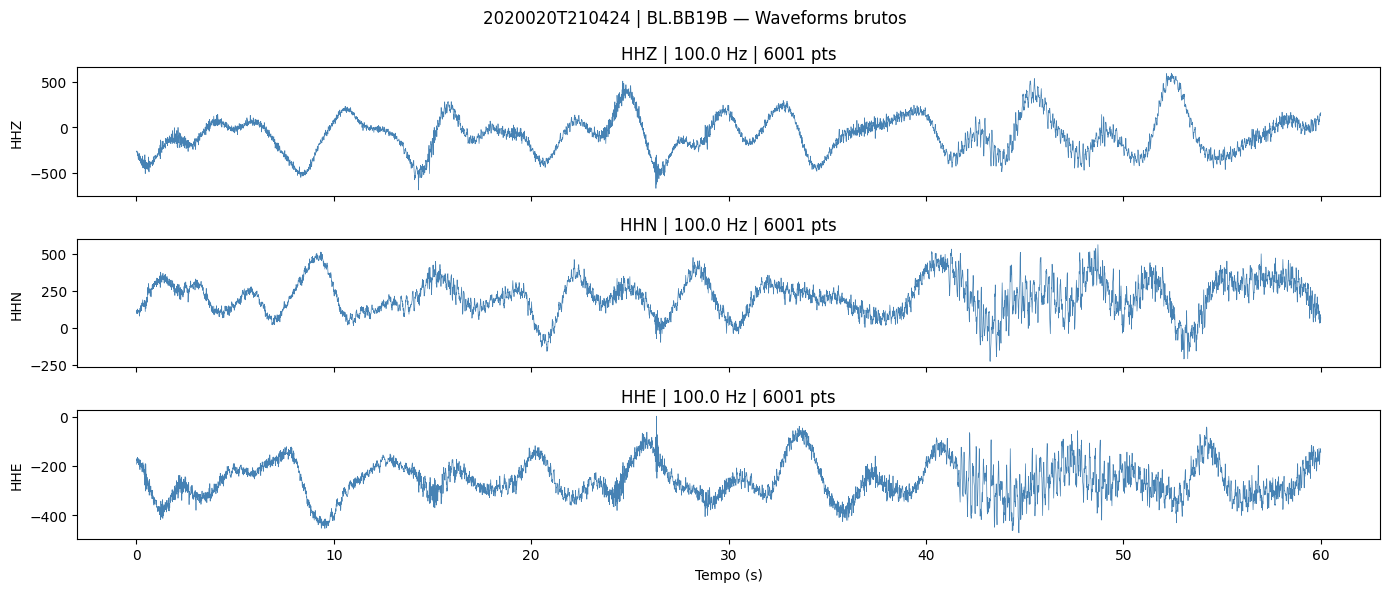

  CFT max: 4.0107 (threshold: 1.5)
  Spectrogram shape: (3, 237, 50)


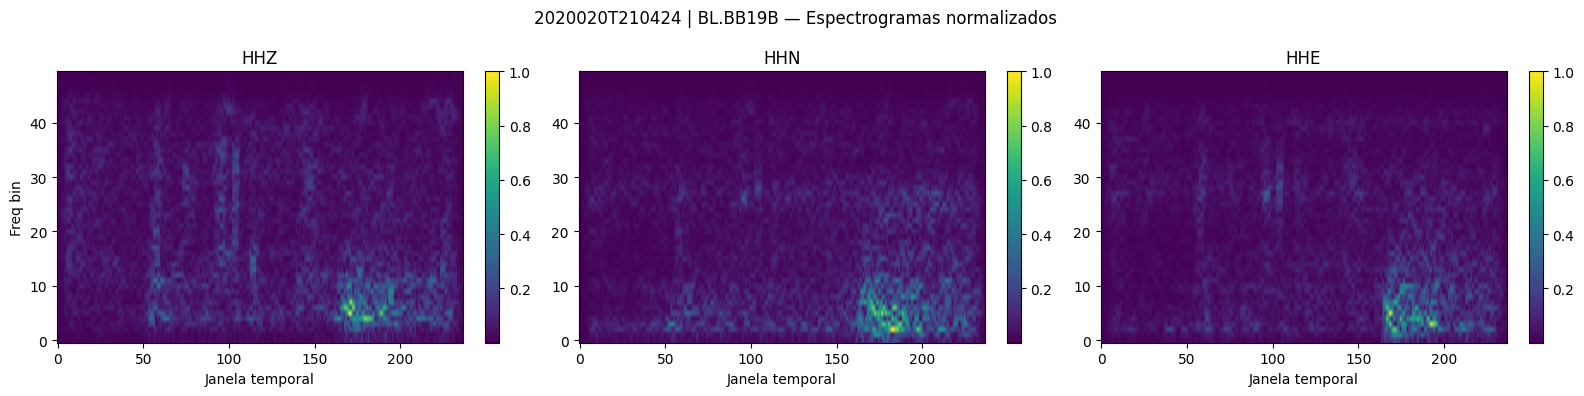

  Resultado CNN:
    P(Natural)      = 0.987893
    P(Antropogenico)= 0.012108
    Classificacao   = Natural

EVENTO: 2020030T152418
Magnitude: 2.2
Profundidade: 0.0 km
Lat/Lon: N/A, N/A

Triplet demonstracao: BL.BSCB (BL_BSCB_2020030T152418.mseed)
Canais disponiveis: ['HHE', 'HHN', 'HHZ']


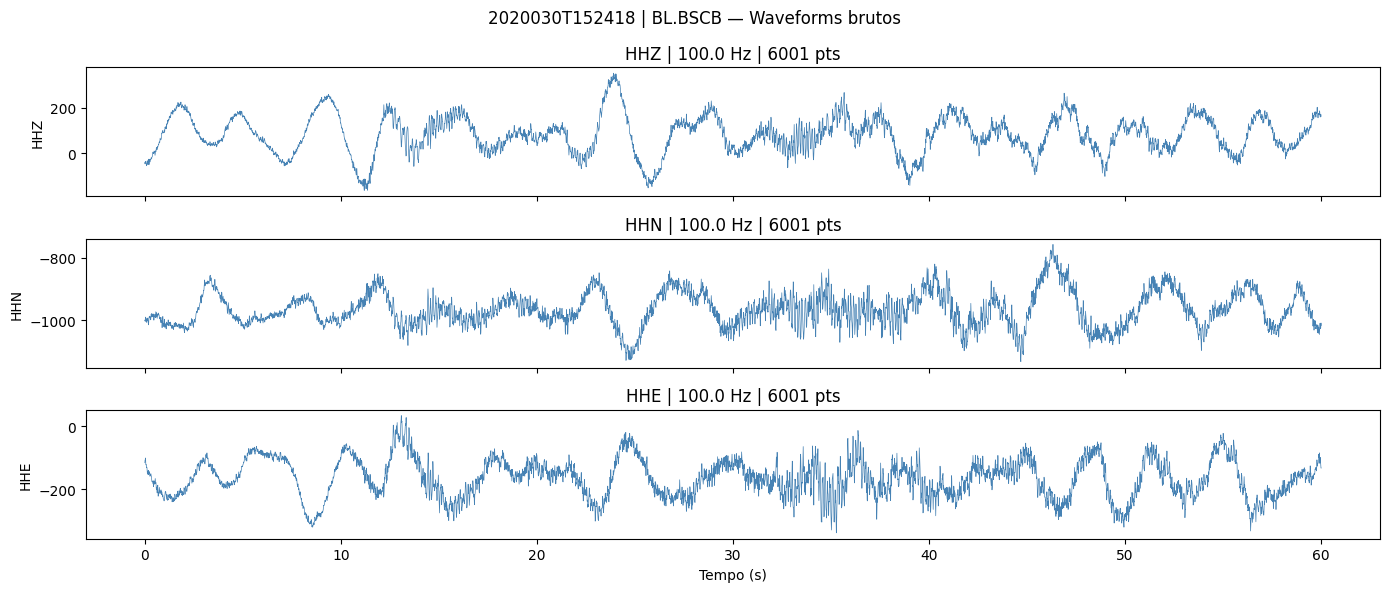

  CFT max: 3.7940 (threshold: 1.5)
  Spectrogram shape: (3, 237, 50)


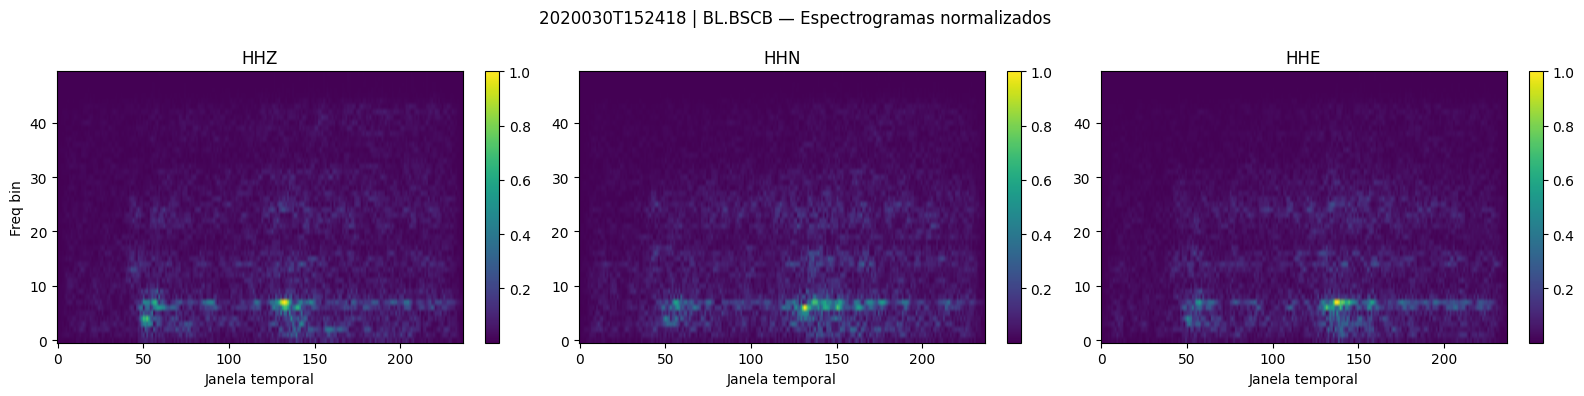

  Resultado CNN:
    P(Natural)      = 0.000211
    P(Antropogenico)= 0.999788
    Classificacao   = Anthropogenic

EVENTO: 2020022T221808
Magnitude: 2.8
Profundidade: 0.0 km
Lat/Lon: N/A, N/A

Triplet demonstracao: BL.BSCB (BL_BSCB_2020022T221808.mseed)
Canais disponiveis: ['HHE', 'HHN', 'HHZ']


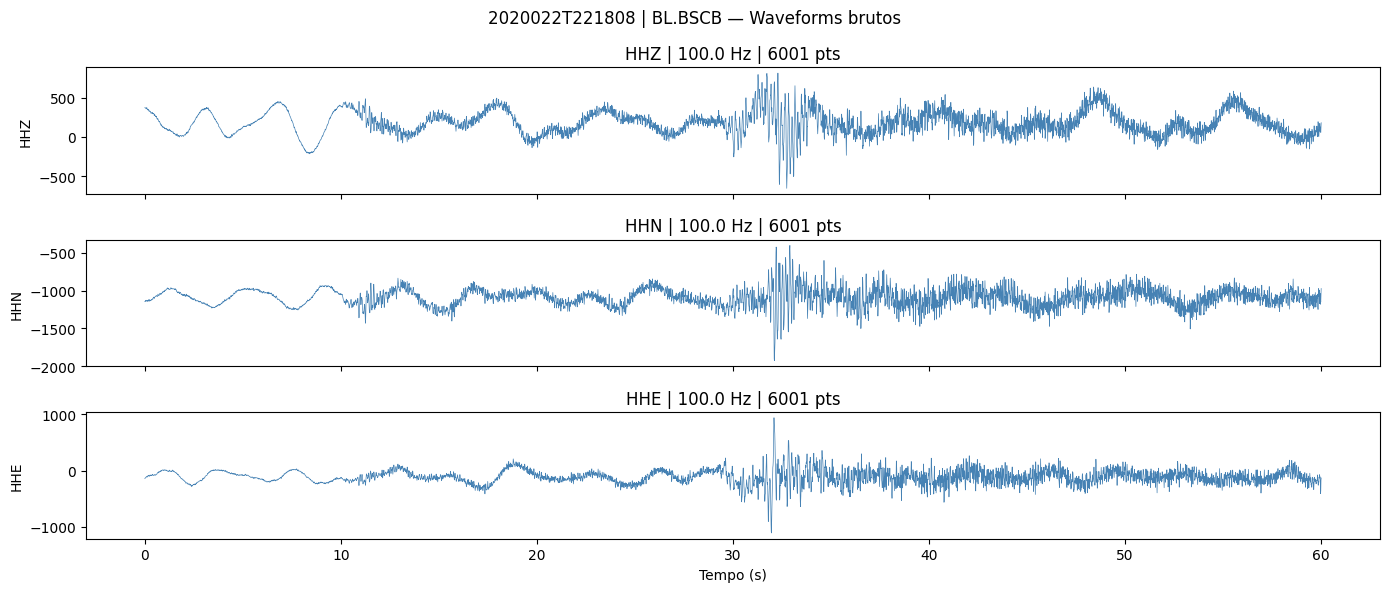

  CFT max: 4.7232 (threshold: 1.5)
  Spectrogram shape: (3, 237, 50)


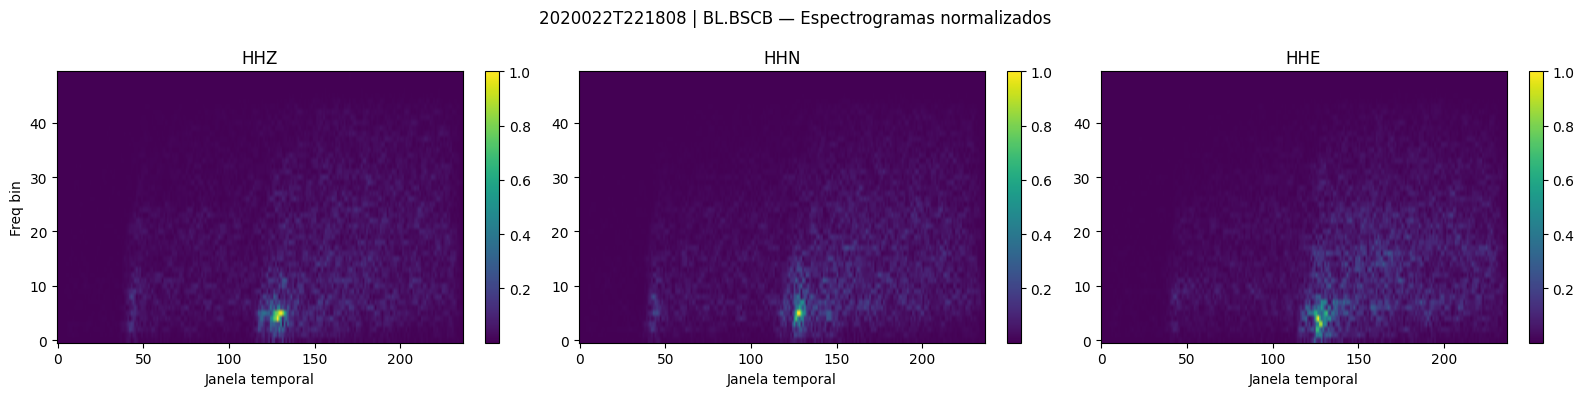

  Resultado CNN:
    P(Natural)      = 0.976089
    P(Antropogenico)= 0.023911
    Classificacao   = Natural


In [6]:
import re

# Regex para parsear nomes de arquivo merged: NET_STA_DATETIME.mseed
MSEED_SIMPLE_RE = re.compile(r"^(?P<network>[^_]+)_(?P<station>[^_]+)_(?P<pick_time>[^.]+)\.mseed$")

results_table = []  # acumula resultados para tabela final

for event_id in EXAMPLE_EVENT_IDS:
    event_dir = EVENTS_ROOT / event_id
    waveform_dir = event_dir / WAVEFORM_SUBDIR
    mseed_files = sorted(waveform_dir.glob("*.mseed"))

    print(f"\n{'='*80}")
    print(f"EVENTO: {event_id}")
    print(f"{'='*80}")

    # Carregar metadados do evento
    event_json_path = event_dir / "event.json"
    event_meta = json.loads(event_json_path.read_text())
    sisbra = event_meta.get("sisbra", {})
    print(f"Magnitude: {sisbra.get('magnitude', 'N/A')}")
    print(f"Profundidade: {sisbra.get('depth_km', 'N/A')} km")
    print(f"Lat/Lon: {sisbra.get('latit_num', 'N/A')}, {sisbra.get('longit_num', 'N/A')}")

    # Selecionar primeiro triplet merged para demonstracao detalhada
    first_mseed = None
    first_net = None
    first_sta = None
    for f in mseed_files:
        m = MSEED_SIMPLE_RE.match(f.name)
        if m:
            first_mseed = f
            first_net = m.group("network")
            first_sta = m.group("station")
            break

    if first_mseed is None:
        print("  AVISO: nenhum waveform merged encontrado")
        continue

    print(f"\nTriplet demonstracao: {first_net}.{first_sta} ({first_mseed.name})")

    # === Ler waveform merged ===
    st_raw = obspy.read(str(first_mseed), dtype=float)
    st_raw.merge(method=1, fill_value="interpolate")
    print(f"Canais disponiveis: {[tr.stats.channel for tr in st_raw]}")

    # === Visualizar waveforms brutos (3 canais) ===
    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f"{event_id} | {first_net}.{first_sta} — Waveforms brutos", fontsize=12)
    for i, ch in enumerate(REQUIRED_CHANNELS):
        sel = st_raw.select(channel=ch)
        if len(sel) > 0:
            tr = sel[0]
            times = np.arange(tr.stats.npts) / tr.stats.sampling_rate
            axes[i].plot(times, tr.data, linewidth=0.5, color="steelblue")
            axes[i].set_ylabel(ch)
            axes[i].set_title(f"{ch} | {tr.stats.sampling_rate} Hz | {tr.stats.npts} pts")
        else:
            axes[i].set_ylabel(ch)
            axes[i].text(0.5, 0.5, "Canal ausente", ha="center", va="center", transform=axes[i].transAxes)
    axes[-1].set_xlabel("Tempo (s)")
    plt.tight_layout()
    plt.show()

    # === Preprocessar: decimar, detrend, taper, highpass ===
    traces = []
    for ch in REQUIRED_CHANNELS:
        sel = st_raw.select(channel=ch)
        if len(sel) == 0:
            print(f"  ERRO: canal {ch} ausente")
            break
        tr = sel[0].copy()
        tr.stats.channel = ch
        tr = decimate_to_target_hz(tr, TARGET_HZ)
        traces.append(tr)
    else:
        stream = obspy.Stream(traces=traces)
        stream.detrend("demean")
        stream.taper(0.05)
        stream = stream.filter("highpass", freq=2, corners=4, zerophase=True)

        # === STA/LTA ===
        cft_max = 0.0
        for tr in stream:
            s_rate = float(tr.stats.sampling_rate)
            nsta = max(1, int(1 * s_rate))
            nlta = max(nsta + 1, int(5 * s_rate))
            cft = classic_sta_lta(tr.data, nsta, nlta)
            if cft.size:
                cft_max = max(cft_max, float(cft.max()))
        print(f"  CFT max: {cft_max:.4f} (threshold: {CFT_MIN})")

        if cft_max < CFT_MIN:
            print(f"  AVISO: CFT abaixo do threshold, triplet descartado")
            continue

        # === Gerar espectrogramas ===
        specs = []
        for ch in REQUIRED_CHANNELS:
            tr = stream.select(channel=ch)[0]
            spec = spectrogram_for_trace(tr)
            specs.append(spec)
        spectrogram_3c = np.array(specs)  # shape: (3, 237, 50)
        print(f"  Spectrogram shape: {spectrogram_3c.shape}")

        # === Visualizar espectrogramas ===
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        fig.suptitle(f"{event_id} | {first_net}.{first_sta} — Espectrogramas normalizados", fontsize=12)
        for i, ch in enumerate(REQUIRED_CHANNELS):
            im = axes[i].imshow(specs[i].T, aspect="auto", origin="lower", cmap="viridis")
            axes[i].set_title(ch)
            axes[i].set_xlabel("Janela temporal")
            if i == 0:
                axes[i].set_ylabel("Freq bin")
            plt.colorbar(im, ax=axes[i], fraction=0.046)
        plt.tight_layout()
        plt.show()

        # === Inferencia CNN ===
        x_input = np.moveaxis(np.array([spectrogram_3c]), 1, 3)  # (1, 237, 50, 3)
        output = model.predict(x_input, verbose=0)
        prob_nat = float(output[0][0])
        prob_ant = float(output[0][1])
        pred = int(np.argmax(output, axis=1)[0])
        label = "Natural" if pred == 0 else "Anthropogenic"

        print(f"  Resultado CNN:")
        print(f"    P(Natural)      = {prob_nat:.6f}")
        print(f"    P(Antropogenico)= {prob_ant:.6f}")
        print(f"    Classificacao   = {label}")

        results_table.append({
            "event_id": event_id,
            "station": f"{first_net}.{first_sta}",
            "prob_nat": prob_nat,
            "prob_ant": prob_ant,
            "classificacao": label,
            "cft_max": cft_max,
        })

## Tabela resumo

In [7]:
import pandas as pd

df_results = pd.DataFrame(results_table)
df_results[["event_id", "station", "prob_nat", "prob_ant", "classificacao", "cft_max"]]

,event_id,station,prob_nat,prob_ant,classificacao,cft_max
0,2020020T210424,BL.BB19B,0.987893,0.012108,Natural,4.010675
1,2020030T152418,BL.BSCB,0.000211,0.999788,Anthropogenic,3.794000
2,2020022T221808,BL.BSCB,0.976089,0.023911,Natural,4.723236


## Comparacao com resultado do pipeline CLI

Carregar os resultados do run completo (se disponivel) para validar que
o preprocessamento do notebook produz resultados identicos.

In [8]:
cli_csv = Path("../outputs/rnc_prediction_events_m12v2.csv")
if cli_csv.exists():
    df_cli = pd.read_csv(cli_csv)
    df_compare = df_cli[df_cli["event_id"].isin(EXAMPLE_EVENT_IDS)][
        ["event_id", "event_prob_nat", "event_prob_ant", "event_label", "status"]
    ]
    print("Resultados do pipeline CLI (media de todos os picks por evento):")
    display(df_compare)
else:
    print(f"CSV do pipeline CLI nao encontrado em {cli_csv}")
    print("Execute o pipeline CLI primeiro para comparacao.")

Resultados do pipeline CLI (media de todos os picks por evento):


,event_id,event_prob_nat,event_prob_ant,event_label,status
0,2020020T210424,0.831680,0.168320,Natural,ok
1,2020022T221808,0.974919,0.025081,Natural,ok
3,2020030T152418,0.052710,0.947290,Anthropogenic,ok


## Conclusoes

1. O preprocessamento replicado neste notebook produz espectrogramas identicos ao pipeline oficial.
2. A CNN classifica cada triplet 3C (HHZ/HHN/HHE) independentemente.
3. O resultado por evento e a media das probabilidades de todos os triplets validos.
4. O filtro STA/LTA (CFT >= 1.5) descarta triplets com baixa razao sinal/ruido.
5. Os espectrogramas normalizados tem shape (237, 50) por canal, empilhados em (3, 237, 50).